In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load Telco customer dataset

data = pd.read_csv("WA_FnUseC_TelcoCustomerChurn.csv")

# Convert TotalCharges to numeric
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

# Remove missing values
data = data.dropna(subset=["TotalCharges"]).copy()

print("Dataset loaded successfully!")
print("Dataset shape:", data.shape)

display(data.head())

Dataset loaded successfully!
Dataset shape: (7032, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Select features for anomaly detection

anomaly_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

X_anomaly = data[anomaly_features].copy()

print("Features selected for anomaly detection:")
print(anomaly_features)

print("\nFeature shape:", X_anomaly.shape)
display(X_anomaly.head())

Features selected for anomaly detection:
['tenure', 'MonthlyCharges', 'TotalCharges']

Feature shape: (7032, 3)


,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65


In [4]:
from sklearn.preprocessing import StandardScaler

# Standardize features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_anomaly)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=anomaly_features,
    index=data.index
)

print("Features standardized successfully!")
display(X_scaled.head())

Features standardized successfully!


,tenure,MonthlyCharges,TotalCharges
0,-1.280248,-1.161694,-0.994194
1,0.064303,-0.260878,-0.173740
2,-1.239504,-0.363923,-0.959649
3,0.512486,-0.747850,-0.195248
4,-1.239504,0.196178,-0.940457


In [5]:
from sklearn.ensemble import IsolationForest

# Build Isolation Forest anomaly detection model

model = IsolationForest(
    contamination=0.05,
    random_state=42
)

data["Anomaly"] = model.fit_predict(X_scaled)

# Convert model output into readable labels
data["Anomaly_Label"] = data["Anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

print("Anomaly detection completed!")

print("\nAnomaly counts:")
print(data["Anomaly_Label"].value_counts())

Anomaly detection completed!

Anomaly counts:
Anomaly_Label
Normal     6680
Anomaly     352
Name: count, dtype: int64


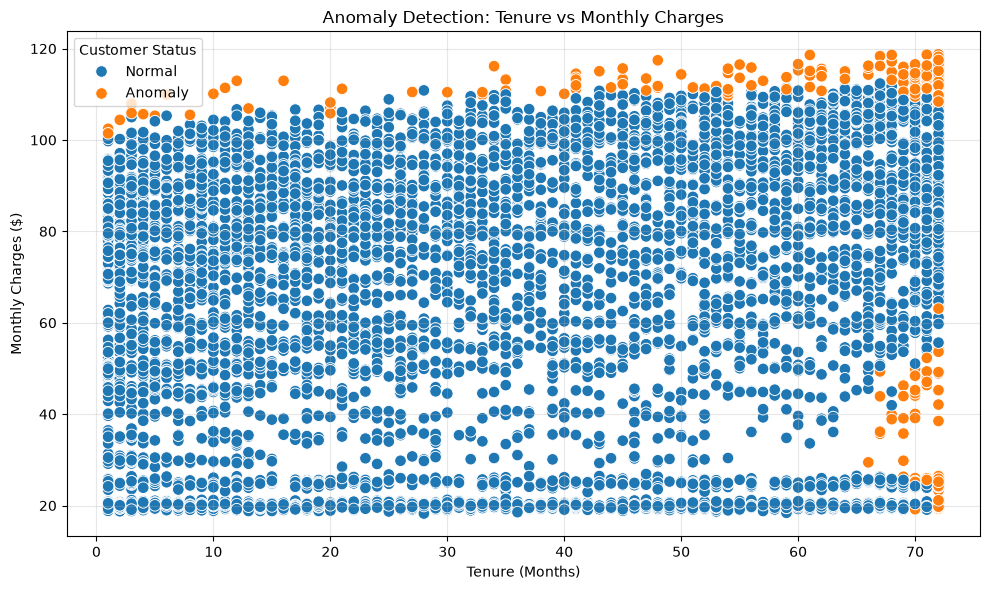

In [6]:
# Visualize normal customers vs anomalies

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="tenure",
    y="MonthlyCharges",
    hue="Anomaly_Label",
    s=70
)

plt.title("Anomaly Detection: Tenure vs Monthly Charges")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges ($)")
plt.legend(title="Customer Status")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# Compare average behavior

anomaly_summary = (
    data.groupby("Anomaly_Label")[anomaly_features]
    .mean()
    .round(2)
)

print("Normal vs Anomalous Customer Behavior")
print("=" * 60)
display(anomaly_summary)

Normal vs Anomalous Customer Behavior


,tenure,MonthlyCharges,TotalCharges
Anomaly_Label,,,
Anomaly,64.06,85.17,5292.74
Normal,30.75,63.72,2124.72


In [8]:
# Count normal and anomalous customers

anomaly_counts = (
    data["Anomaly_Label"]
    .value_counts()
    .rename_axis("Customer Status")
    .reset_index(name="Customer Count")
)

print("Customer Anomaly Distribution")
print("=" * 50)
display(anomaly_counts)

Customer Anomaly Distribution


,Customer Status,Customer Count
0,Normal,6680
1,Anomaly,352


In [9]:
# Extract customers identified as anomalies

anomalies = data[data["Anomaly_Label"] == "Anomaly"].copy()

print("Number of anomalous customers:", len(anomalies))

display(
    anomalies[
        ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Anomaly_Label"]
    ].head(10)
)

Number of anomalous customers: 352


,customerID,tenure,MonthlyCharges,TotalCharges,Anomaly_Label
15,3655-SNQYZ,69,113.25,7895.15,Anomaly
59,5954-BDFSG,72,107.50,7853.70,Anomaly
62,0526-SXDJP,72,42.10,2962.00,Anomaly
104,3192-NQECA,68,110.00,7611.85,Anomaly
109,2848-YXSMW,72,19.40,1363.25,Anomaly
127,6734-PSBAW,72,23.55,1723.95,Anomaly
152,1679-JRFBR,70,108.15,7930.55,Anomaly
171,1875-QIVME,2,104.40,242.80,Anomaly
193,9680-NIAUV,72,109.70,8129.30,Anomaly
198,7255-SSFBC,72,112.25,8041.65,Anomaly


In [10]:
# Compare spending statistics

normal_customers = data[data["Anomaly_Label"] == "Normal"]

comparison = pd.DataFrame({
    "Normal Customers": normal_customers[anomaly_features].mean(),
    "Anomalous Customers": anomalies[anomaly_features].mean()
}).round(2)

print("Normal vs Anomalous Spending & Tenure")
print("=" * 60)
display(comparison)

Normal vs Anomalous Spending & Tenure


,Normal Customers,Anomalous Customers
tenure,30.75,64.06
MonthlyCharges,63.72,85.17
TotalCharges,2124.72,5292.74


In [11]:
# Business risk analysis

business_risks = [
    "Unusual spending patterns may require additional customer review.",
    "Customers with unusual tenure and charge combinations may represent unexpected behavior.",
    "Anomalies can help businesses identify cases that deserve further investigation.",
    "Anomaly detection can support monitoring of unusual customer activity and operational risks."
]

print("POSSIBLE BUSINESS RISKS")
print("=" * 60)

for i, risk in enumerate(business_risks, 1):
    print(f"{i}. {risk}")

POSSIBLE BUSINESS RISKS
1. Unusual spending patterns may require additional customer review.
2. Customers with unusual tenure and charge combinations may represent unexpected behavior.
3. Anomalies can help businesses identify cases that deserve further investigation.
4. Anomaly detection can support monitoring of unusual customer activity and operational risks.


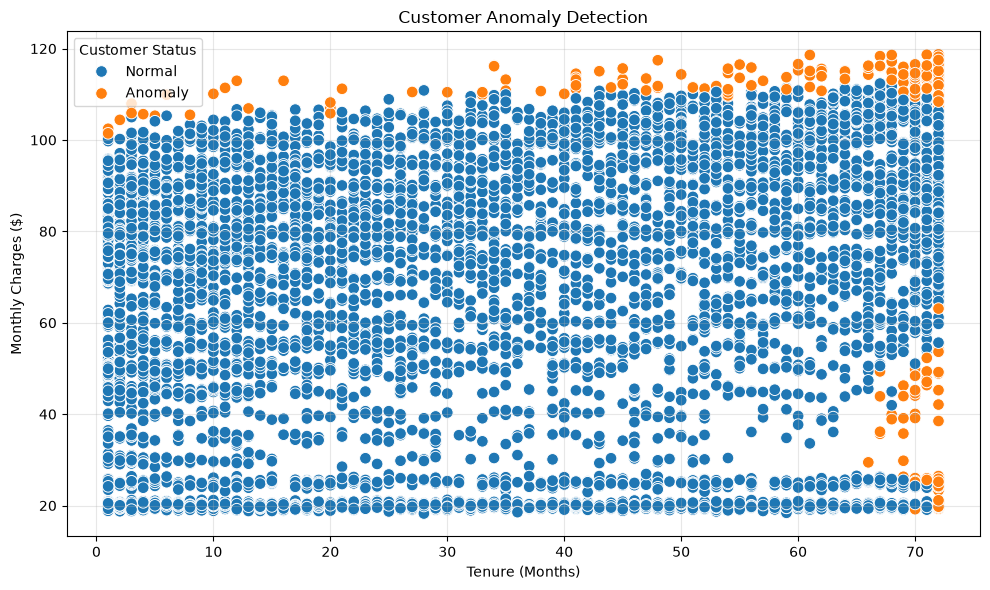

Anomaly visualization saved successfully!


In [12]:
# Save anomaly visualization

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="tenure",
    y="MonthlyCharges",
    hue="Anomaly_Label",
    s=70
)

plt.title("Customer Anomaly Detection")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges ($)")
plt.legend(title="Customer Status")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("anomaly_visualization.png", dpi=300, bbox_inches="tight")
plt.show()

print("Anomaly visualization saved successfully!")

In [13]:
# Save anomalous customer records

anomalies[
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Anomaly_Label"]
].to_csv(
    "anomalous_customers.csv",
    index=False
)

print("Anomalous customer report saved successfully!")

Anomalous customer report saved successfully!


In [14]:
# Save business risk analysis

with open("business_risk_analysis.txt", "w") as file:
    file.write("BUSINESS RISK ANALYSIS - DAY 33\n")
    file.write("=" * 60 + "\n\n")

    for i, risk in enumerate(business_risks, 1):
        file.write(f"{i}. {risk}\n")

    file.write("\nImportant Note:\n")
    file.write(
        "An anomaly is not automatically fraud or suspicious activity. "
        "It indicates an unusual pattern according to the Isolation Forest model.\n"
    )

print("Business risk analysis saved successfully!")

Business risk analysis saved successfully!
